# Кейсы 1 и 3 — численная часть

Ноутбук реализует программные пункты двух кейсов:
**Кейс 1** — спектральная задача для оператора с ядром $K(x,t)=\min(x,t)$;
**Кейс 3** — изометрическое вложение по матрице расстояний (классический MDS).

Аналитические выводы вынесены в отдельный PDF-отчёт. Здесь — код, графики и краткие выводы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.linalg import orthogonal_procrustes

rcParams.update({"figure.dpi":120,"savefig.dpi":120,"font.size":11,
                 "axes.grid":True,"grid.alpha":0.3,"figure.autolayout":True})
np.set_printoptions(precision=6, suppress=True)
rng = np.random.default_rng(42)

---
# Кейс 1. Оператор с ядром $\min(x,t)$

Эталонные формулы (выведены в отчёте): $\lambda_k=\dfrac{1}{\pi^2(k-\tfrac12)^2}$,
$\varphi_k(x)=\sqrt2\sin\big((k-\tfrac12)\pi x\big)$.

In [2]:
def lambda_exact(k):
    k = np.asarray(k, float)
    return 1.0/(np.pi**2*(k-0.5)**2)

def phi_exact(k, x):
    return np.sqrt(2.0)*np.sin((k-0.5)*np.pi*np.asarray(x, float))

def uniform_grid(n):
    return np.linspace(0.0, 1.0, n+1)

def weights(kind, n):
    h = 1.0/n
    w = np.zeros(n+1)
    if kind == "rectangle":
        w[1:] = h
    elif kind == "trapezoid":
        w[:] = h; w[0] = w[-1] = h/2
    elif kind == "simpson":
        if n % 2 != 0:
            raise ValueError("Для формулы Симпсона n должно быть чётным")
        w[0] = w[-1] = h/3; w[1:-1:2] = 4*h/3; w[2:-1:2] = 2*h/3
    else:
        raise ValueError("Неизвестный тип квадратуры")
    return w

def kernel_min(x):
    return np.minimum.outer(x, x)

def discretize(x, w, K=None):
    if K is None: K = kernel_min(x)
    sw = np.sqrt(w)
    return K*w[None,:], sw[:,None]*K*sw[None,:], K

def solve_spectrum(x, w, K=None, npairs=None):
    A, B, K = discretize(x, w, K)
    vals, vecs = np.linalg.eigh(B)
    o = np.argsort(vals)[::-1]
    vals, vecs = vals[o], vecs[:,o]
    sw = np.sqrt(np.where(w>0, w, np.nan))
    phi = np.where(np.isfinite(vecs/sw[:,None]), vecs/sw[:,None], 0.0)
    for j in range(phi.shape[1]):
        c = phi[:,j]
        s = c[1] if abs(c[1])>1e-12 else c[np.argmax(np.abs(c))]
        if s < 0: phi[:,j] *= -1
    if npairs is not None: vals, phi = vals[:npairs], phi[:,:npairs]
    return vals, phi

def dl2(f, g, w):
    return np.sum(f*g*w)

def eigfun_err(phi_num, phi_ex, w):
    s = np.sign(dl2(phi_num, phi_ex, w)) or 1.0
    return np.sqrt(np.sum((s*phi_num-phi_ex)**2*w))

## Свойства матрицы Грама $G_{ij}=\min(x_i,x_j)$ (п. 2)

In [3]:
n = 100
x = uniform_grid(n)
G = kernel_min(x)
sym = np.max(np.abs(G-G.T))
ev = np.linalg.eigvalsh(G)
z = rng.normal(size=(2000, len(x)))
quad = np.einsum("ki,ij,kj->k", z, G, z)
pd.DataFrame({"проверка":["max|G-G^T|","min eig(G)","min z^T G z"],
             "значение":[f"{sym:.2e}", f"{ev.min():.2e}", f"{quad.min():.2e}"]})

,проверка,значение
0,max|G-G^T|,0.00e+00
1,min eig(G),0.00e+00
2,min z^T G z,1.32e+00


**Вывод.** Матрица симметрична до машинной точности, спектр неотрицателен, и $z^\top Gz\ge0$
на всех проверенных векторах — $G$ положительно полуопределена, как и предсказывает теория.

## Аналитические $\lambda_k$ и $\varphi_k$ (п. 4)

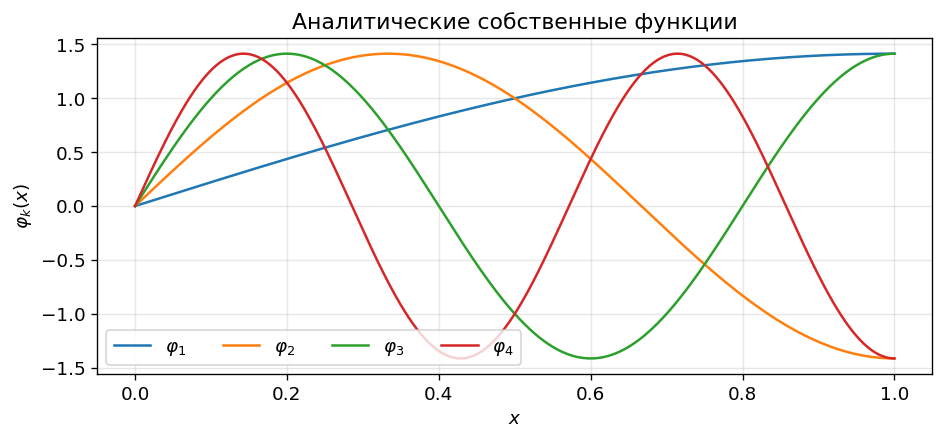

,k,lambda_k
0,1,0.405285
1,2,0.045032
2,3,0.016211
3,4,0.008271
4,5,0.005004
5,6,0.003349


In [4]:
ks = np.arange(1, 7)
xg = uniform_grid(400)
fig, ax = plt.subplots(figsize=(8,3.8))
for k in range(1,5):
    ax.plot(xg, phi_exact(k, xg), label=fr"$\varphi_{k}$")
ax.set(title="Аналитические собственные функции", xlabel="$x$", ylabel=r"$\varphi_k(x)$")
ax.legend(ncol=4)
plt.show()
pd.DataFrame({"k":ks, "lambda_k":lambda_exact(ks)})

**Вывод.** Функции удовлетворяют $\varphi_k(0)=0$ и $\varphi_k'(1)=0$; собственные значения
убывают как $k^{-2}$.

## Дискретизация: квадратуры и матрицы $K,A,B$ (п. 5)

In [5]:
n = 50
x = uniform_grid(n)
rows = []
for kind in ["rectangle","trapezoid","simpson"]:
    w = weights(kind, n)
    A, B, K = discretize(x, w)
    rows.append([kind, w.sum(), np.max(np.abs(B-B.T))])
pd.DataFrame(rows, columns=["квадратура","sum(w)","||B-B^T||"])

,квадратура,sum(w),||B-B^T||
0,rectangle,1.0,0.000000e+00
1,trapezoid,1.0,1.734723e-18
2,simpson,1.0,3.469447e-18


**Вывод.** Все три набора весов нормированы ($\sum w=1$), а симметризованная матрица
$B=W^{1/2}KW^{1/2}$ симметрична — можно применять устойчивое разложение `eigh`.

## Сравнение численного и аналитического спектра (пп. 7–8)

In [6]:
Ns = [20, 50, 100, 200]
Kp = 5
rows_l, rows_p = [], []
for n in Ns:
    x = uniform_grid(n); w = weights("trapezoid", n)
    vals, phi = solve_spectrum(x, w, npairs=Kp)
    lam = lambda_exact(np.arange(1,Kp+1))
    rows_l.append([f"{abs(vals[k]-lam[k]):.1e}" for k in range(Kp)])
    rows_p.append([f"{eigfun_err(phi[:,k], phi_exact(k+1,x), w):.1e}" for k in range(Kp)])
cols = [f"k={k}" for k in range(1,Kp+1)]
display(pd.DataFrame(rows_l, index=[f"n={n}" for n in Ns], columns=cols))
pd.DataFrame(rows_p, index=[f"n={n}" for n in Ns], columns=cols)

,k=1,k=2,k=3,k=4,k=5
n=20,2.1e-04,2.1e-04,2.1e-04,2.1e-04,2.1e-04
n=50,3.3e-05,3.3e-05,3.3e-05,3.3e-05,3.3e-05
n=100,8.3e-06,8.3e-06,8.3e-06,8.3e-06,8.3e-06
n=200,2.1e-06,2.1e-06,2.1e-06,2.1e-06,2.1e-06


,k=1,k=2,k=3,k=4,k=5
n=20,3.1e-16,1.1e-15,2.5e-15,3.2e-15,8.0e-15
n=50,2.8e-16,6.0e-16,1.9e-15,4.3e-15,6.4e-15
n=100,7.9e-16,2.6e-15,4.4e-15,1.1e-14,1.3e-14
n=200,4.0e-16,3.3e-15,5.2e-15,9.1e-15,1.6e-14


Первая таблица — ошибка собственных значений $e^{(\lambda)}_k$, вторая — собственных функций
$e^{(\varphi)}_k$.

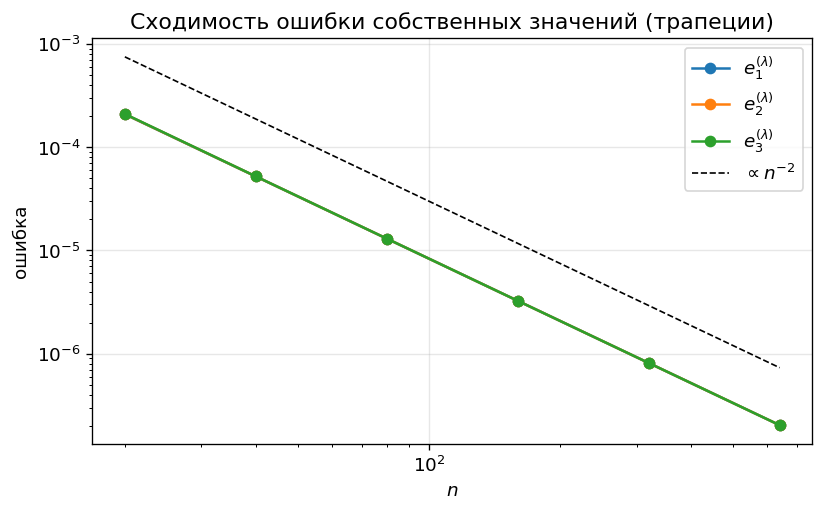

In [7]:
Nf = [20,40,80,160,320,640]
err = {k:[] for k in range(1,4)}
for n in Nf:
    x = uniform_grid(n); w = weights("trapezoid", n)
    vals,_ = solve_spectrum(x, w, npairs=3)
    for k in range(1,4): err[k].append(abs(vals[k-1]-lambda_exact(k)))
fig, ax = plt.subplots(figsize=(7,4.4))
for k in range(1,4): ax.loglog(Nf, err[k], "o-", label=fr"$e^{{(\lambda)}}_{k}$")
r = np.array(Nf, float); ax.loglog(r, 0.3/r**2, "k--", lw=1, label=r"$\propto n^{-2}$")
ax.set(title="Сходимость ошибки собственных значений (трапеции)", xlabel="$n$", ylabel="ошибка")
ax.legend()
plt.show()

### Наложение численных и аналитических собственных функций (пп. 7b, 8e)

Кроме таблицы ошибок построим прямое сравнение первых собственных функций: сплошная линия — аналитическая формула, пунктир — численное решение после фиксации знака.


In [ ]:
n = 100
x = uniform_grid(n)
w = weights("trapezoid", n)
vals, phi_num = solve_spectrum(x, w, npairs=4)

fig, ax = plt.subplots(figsize=(8, 4.2))
for k in range(1, 5):
    ax.plot(x, phi_exact(k, x), lw=2.0, label=fr"аналит. $\varphi_{k}$")
    ax.plot(x, phi_num[:, k-1], "--", lw=1.2, label=fr"числ. $\varphi_{k}$")
ax.set(title="Наложение аналитических и численных собственных функций",
       xlabel="$x$", ylabel=r"$\varphi_k(x)$")
ax.legend(ncol=2, fontsize=8)
plt.show()

pd.DataFrame({
    "k": np.arange(1, 5),
    "lambda_exact": lambda_exact(np.arange(1, 5)),
    "lambda_num": vals,
    "e_phi": [eigfun_err(phi_num[:, k-1], phi_exact(k, x), w) for k in range(1, 5)]
})


**Вывод.** Численные кривые практически совпадают с аналитическими. Небольшие отличия видны только из-за дискретизации и выбора сетки; знак фиксируется отдельно, потому что собственная функция определена с точностью до множителя $-1$.


**Вывод.** Ошибка $\lambda_k$ убывает как $O(n^{-2})$ (параллельна эталонному наклону), а ошибка
собственных функций — на уровне машинного нуля: дискретный синус оказывается точным собственным
вектором дискретного оператора, тогда как квадратура вносит погрешность только в сами значения.

## Усечённое разложение Мерсера (пп. 9–10)

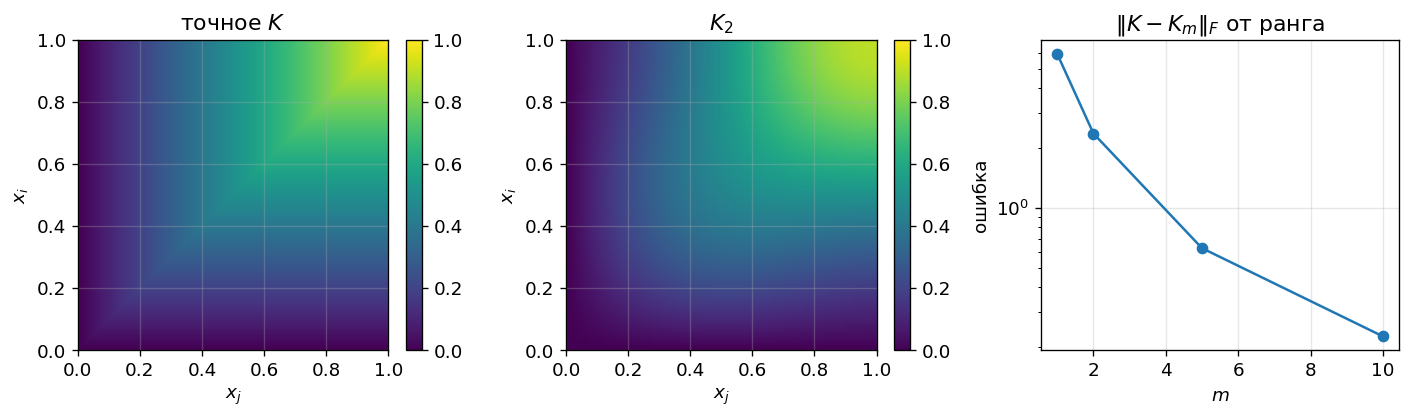

,m,||K-K_m||_F
0,1,5.9432
1,2,2.3705
2,5,0.6300
3,10,0.2273


In [8]:
n = 120
x = uniform_grid(n)
K = kernel_min(x)
ms = [1,2,5,10]
fro = []
for m in ms:
    Km = sum(lambda_exact(k)*np.outer(phi_exact(k,x), phi_exact(k,x)) for k in range(1,m+1))
    fro.append(np.linalg.norm(K-Km))
fig, ax = plt.subplots(1,3, figsize=(12,3.6))
for a,(t,m) in zip(ax[:2], [("точное $K$",None),("$K_2$",2)]):
    M = K if m is None else sum(lambda_exact(k)*np.outer(phi_exact(k,x),phi_exact(k,x)) for k in range(1,m+1))
    im = a.imshow(M, origin="lower", extent=[0,1,0,1], cmap="viridis", vmin=0, vmax=1)
    a.set(title=t, xlabel="$x_j$", ylabel="$x_i$"); fig.colorbar(im, ax=a, fraction=0.046)
ax[2].semilogy(ms, fro, "o-")
ax[2].set(title=r"$\|K-K_m\|_F$ от ранга", xlabel="$m$", ylabel="ошибка")
plt.show()
pd.DataFrame({"m":ms, "||K-K_m||_F":[f"{v:.4f}" for v in fro]})

**Вывод.** Уже при $m=5$ ошибка падает на порядок относительно $m=1$ — из-за быстрого
($\sim k^{-2}$) убывания спектра первые пары доминируют, и ядро хорошо приближается малым рангом.

## Влияние дискретизации и шума (п. 11)

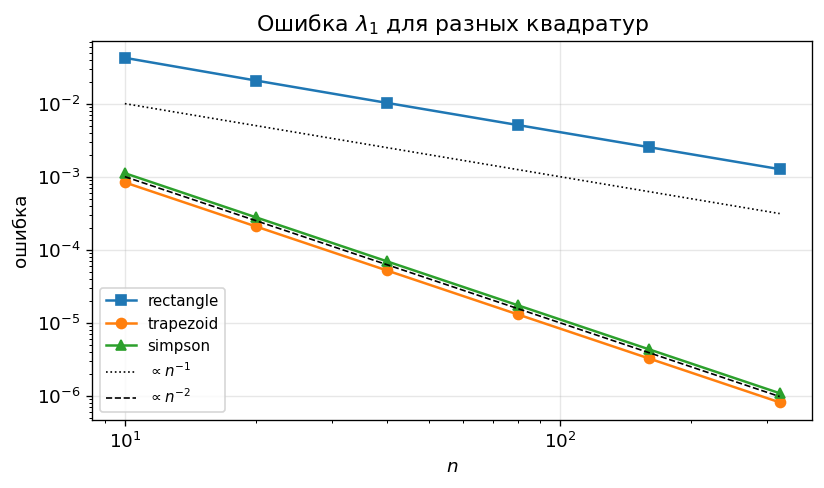

In [9]:
Nq = [10,20,40,80,160,320]
res = {q:[] for q in ["rectangle","trapezoid","simpson"]}
for n in Nq:
    x = uniform_grid(n)
    for q in res:
        vals,_ = solve_spectrum(x, weights(q,n), npairs=1)
        res[q].append(abs(vals[0]-lambda_exact(1)))
fig, ax = plt.subplots(figsize=(7,4.2))
for q,mk in zip(res, ["s","o","^"]): ax.loglog(Nq, res[q], mk+"-", label=q)
r = np.array(Nq, float)
ax.loglog(r, 0.1/r, "k:", lw=1, label=r"$\propto n^{-1}$")
ax.loglog(r, 0.1/r**2, "k--", lw=1, label=r"$\propto n^{-2}$")
ax.set(title=r"Ошибка $\lambda_1$ для разных квадратур", xlabel="$n$", ylabel="ошибка")
ax.legend(fontsize=9)
plt.show()

**Вывод.** Прямоугольники дают первый порядок $O(n^{-1})$, трапеции и Симпсон — второй
$O(n^{-2})$. Симпсон не превосходит трапеции: излом ядра $\min$ вдоль диагонали ограничивает порядок
сходимости.

### Сравнение равномерной и неравномерной сетки (п. 11b)

Для неравномерной сетки используем те же трапециевидные веса, но интервалы между узлами различаются. Чтобы сравнение было честным, число узлов остаётся тем же.


In [ ]:
def nonuniform_grid(n, power=1.7):
    u = np.linspace(0.0, 1.0, n+1)
    return u**power

def trapezoid_weights_from_grid(x):
    x = np.asarray(x, float)
    w = np.zeros_like(x)
    w[0] = (x[1] - x[0]) / 2
    w[-1] = (x[-1] - x[-2]) / 2
    w[1:-1] = (x[2:] - x[:-2]) / 2
    return w

Ns_grid = [20, 40, 80, 160, 320]
rows = []
err_uniform, err_nonuniform = [], []
for n in Ns_grid:
    xu = uniform_grid(n)
    wu = weights("trapezoid", n)
    vu, _ = solve_spectrum(xu, wu, npairs=3)

    xn = nonuniform_grid(n)
    wn = trapezoid_weights_from_grid(xn)
    vn, _ = solve_spectrum(xn, wn, npairs=3)

    eu = abs(vu[0] - lambda_exact(1))
    en = abs(vn[0] - lambda_exact(1))
    err_uniform.append(eu)
    err_nonuniform.append(en)
    rows.append([n, eu, en, wn.sum(), np.min(np.diff(xn)), np.max(np.diff(xn))])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(Ns_grid, err_uniform, "o-", label="равномерная сетка")
ax.loglog(Ns_grid, err_nonuniform, "s-", label="неравномерная сетка")
ax.set(title=r"Ошибка $\lambda_1$ на равномерной и неравномерной сетке",
       xlabel="$n$", ylabel="ошибка")
ax.legend()
plt.show()

pd.DataFrame(rows, columns=["n", "err uniform", "err nonuniform", "sum(w)", "min шаг", "max шаг"])


**Вывод.** Неравномерная сетка тоже даёт сходимость, но обычно хуже по точности при том же числе узлов: часть отрезка описывается слишком грубо. Для гладких участков это не так критично, но для ядра с изломом вдоль диагонали равномерное покрытие оказывается стабильнее.


### Возмущённое ядро $K_\varepsilon=K+\varepsilon R$ (п. 11c,d)

Добавим к ядру симметричную случайную добавку с нулевой диагональю и посмотрим, как меняются первые собственные значения и собственные функции.


In [ ]:
n = 120
x = uniform_grid(n)
w = weights("trapezoid", n)
K0 = kernel_min(x)
R = rng.normal(size=K0.shape)
R = (R + R.T) / 2
np.fill_diagonal(R, 0)
R = R / np.linalg.norm(R) * np.linalg.norm(K0)

eps_list = [0.0, 0.01, 0.03, 0.05, 0.10]
rows = []
curves = {}
for eps in eps_list:
    Keps = K0 + eps * R
    vals_eps, phi_eps = solve_spectrum(x, w, Keps, npairs=3)
    curves[eps] = phi_eps[:, 0]
    rows.append([
        eps,
        vals_eps[0], vals_eps[1], vals_eps[2],
        abs(vals_eps[0] - lambda_exact(1)),
        eigfun_err(phi_eps[:, 0], phi_exact(1, x), w),
        eigfun_err(phi_eps[:, 1], phi_exact(2, x), w)
    ])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for j in range(3):
    ax[0].plot(eps_list,
               [solve_spectrum(x, w, K0 + eps * R, npairs=3)[0][j] for eps in eps_list],
               "o-", label=fr"$\lambda_{j+1}$")
ax[0].set(title="Изменение первых собственных значений", xlabel=r"$\varepsilon$", ylabel=r"$\lambda_k$")
ax[0].legend()

ax[1].plot(x, phi_exact(1, x), lw=2.2, label=r"точная $\varphi_1$")
for eps in eps_list[1:]:
    ax[1].plot(x, curves[eps], "--", lw=1.0, label=fr"$\varepsilon={eps}$")
ax[1].set(title=r"Первая собственная функция при возмущении ядра",
          xlabel="$x$", ylabel=r"$\varphi_1(x)$")
ax[1].legend(fontsize=8)
plt.show()

pd.DataFrame(rows, columns=["eps", "lambda1", "lambda2", "lambda3", "err lambda1", "err phi1", "err phi2"])


**Вывод.** При малом $\varepsilon$ спектр и первые собственные функции меняются плавно. С ростом возмущения увеличиваются ошибки собственных значений и функций: численное решение уже описывает не исходный оператор с ядром $\min(x,t)$, а его зашумлённую версию.


## Данные: винеровский процесс и другие ядра

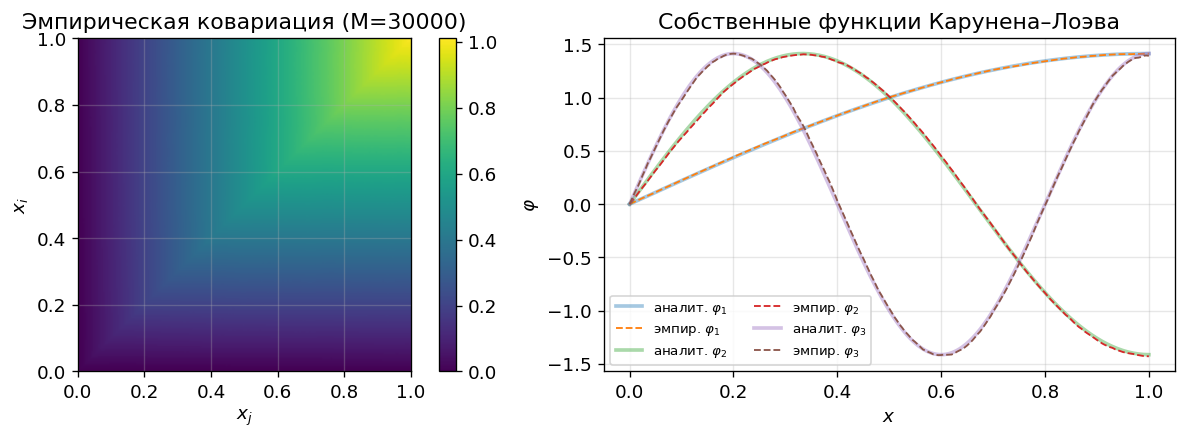

0.015009778468726458


In [10]:
n = 200; M = 30000
x = uniform_grid(n); w = weights("trapezoid", n)
dt = np.diff(x)
incr = rng.normal(size=(M, len(dt)))*np.sqrt(dt)
W = np.zeros((M, n+1)); W[:,1:] = np.cumsum(incr, axis=1)
Kemp = (W.T@W)/M
Kth = kernel_min(x)
rel = np.linalg.norm(Kemp-Kth)/np.linalg.norm(Kth)
vals_e, phi_e = solve_spectrum(x, w, Kemp, npairs=3)
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
im = ax[0].imshow(Kemp, origin="lower", extent=[0,1,0,1], cmap="viridis")
ax[0].set(title=fr"Эмпирическая ковариация (M={M})", xlabel="$x_j$", ylabel="$x_i$")
fig.colorbar(im, ax=ax[0], fraction=0.046)
for k in range(1,4):
    ax[1].plot(x, phi_exact(k,x), lw=2.2, alpha=0.4, label=fr"аналит. $\varphi_{k}$")
    ax[1].plot(x, phi_e[:,k-1], "--", lw=1.1, label=fr"эмпир. $\varphi_{k}$")
ax[1].set(title="Собственные функции Карунена–Лоэва", xlabel="$x$", ylabel=r"$\varphi$")
ax[1].legend(fontsize=8, ncol=2)
plt.show()
print(rel)

**Вывод.** Эмпирическая ковариация винеровского процесса сходится к $\min(x,t)$ (относительная
ошибка ~1–2% при $M=3\cdot10^4$), а её собственные функции совпадают с аналитическими $\varphi_k$.

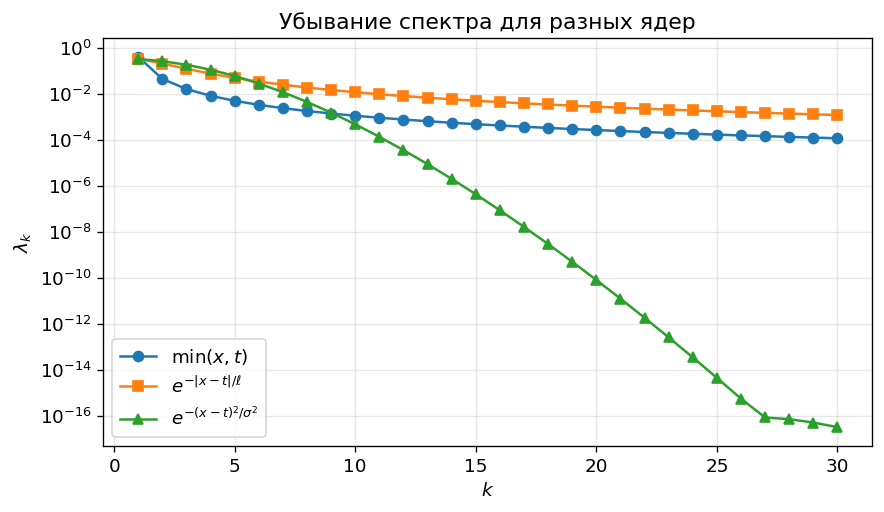

In [11]:
n = 300
x = uniform_grid(n); w = weights("trapezoid", n)
def spec(K, m=30):
    v,_ = solve_spectrum(x, w, K, npairs=m); return v
Kmin = kernel_min(x)
Kou = np.exp(-np.abs(np.subtract.outer(x,x))/0.2)
Kg = np.exp(-(np.subtract.outer(x,x)**2)/0.2**2)
fig, ax = plt.subplots(figsize=(7.5,4.4))
ax.semilogy(range(1,31), spec(Kmin)[:30], "o-", label=r"$\min(x,t)$")
ax.semilogy(range(1,31), spec(Kou)[:30], "s-", label=r"$e^{-|x-t|/\ell}$")
ax.semilogy(range(1,31), np.clip(spec(Kg)[:30],1e-18,None), "^-", label=r"$e^{-(x-t)^2/\sigma^2}$")
ax.set(title="Убывание спектра для разных ядер", xlabel="$k$", ylabel=r"$\lambda_k$")
ax.legend()
plt.show()

**Вывод.** Гладкость ядра управляет спадом спектра: гауссово ядро убывает сверхэкспоненциально
(крайне «низкоранговое»), а ядра с изломом — $\min$ и Орнштейна–Уленбека — лишь степенно $\sim k^{-2}$.

---
# Кейс 3. Изометрическое вложение по матрице расстояний (MDS)

По матрице расстояний $D$ восстанавливаем координаты через двойное центрирование
$B=-\tfrac12 JD^{(2)}J$ и спектральное разложение $B=U\Lambda U^\top$, $Y=U_r\Lambda_r^{1/2}$.

In [12]:
def dist_matrix(Y):
    diff = Y[:,None,:] - Y[None,:,:]
    return np.sqrt((diff**2).sum(-1))

def check_dmat(D):
    return np.max(np.abs(np.diag(D))), np.max(np.abs(D-D.T)), D.min()

def triangle_violation_fraction(D, n_samples=20000):
    n = D.shape[0]
    idx = rng.integers(0, n, size=(n_samples, 3))
    idx = idx[(idx[:,0]!=idx[:,1]) & (idx[:,1]!=idx[:,2]) & (idx[:,0]!=idx[:,2])]
    i,j,k = idx[:,0], idx[:,1], idx[:,2]
    bad = D[i,k] > D[i,j] + D[j,k] + 1e-12
    return bad.mean()

def gram_from_D(D):
    n = D.shape[0]
    J = np.eye(n) - np.ones((n,n))/n
    return -0.5 * J @ (D**2) @ J

def eig_desc(B):
    vals, vecs = np.linalg.eigh(B)
    o = np.argsort(vals)[::-1]
    return vals[o], vecs[:,o]

def embed(B, m):
    vals, vecs = eig_desc(B)
    m = min(m, int(np.sum(vals > 1e-9)))
    L = np.clip(vals[:m], 0, None)
    return vecs[:,:m] * np.sqrt(L)[None,:]

def procrustes_align(Y, X):
    Yc, Xc = Y - Y.mean(0), X - X.mean(0)
    R,_ = orthogonal_procrustes(Yc, Xc)
    return Yc @ R, Xc

## Базовые свойства матрицы расстояний (пп. 2–4)

In [13]:
n = 40
X = rng.normal(size=(n, 3))
D = dist_matrix(X)
diag, sym, mn = check_dmat(D)
Rn = rng.normal(size=(n,n)); Rn = (Rn+Rn.T)/2; np.fill_diagonal(Rn, 0)
Dnoisy = D + 0.3*Rn
pd.DataFrame({
    "величина":["max|diag|","max|D-D^T|","min D","доля нарушений (точные)","доля нарушений (шум 0.3)"],
    "значение":[f"{diag:.1e}", f"{sym:.1e}", f"{mn:.3f}",
                f"{triangle_violation_fraction(D):.4f}", f"{triangle_violation_fraction(Dnoisy):.4f}"]})

,величина,значение
0,max|diag|,0.0e+00
1,max|D-D^T|,0.0e+00
2,min D,0.000
3,доля нарушений (точные),0.0000
4,доля нарушений (шум 0.3),0.0322


**Вывод.** Точная матрица идеальна (нулевая диагональ, симметрия, неотрицательность) и не
нарушает неравенство треугольника; при сильном шуме появляется заметная доля нарушений.

## Двойное центрирование и матрица Грама (пп. 6–7)

Сначала явно построим матрицу квадратов расстояний $D^{(2)}$, центрирующую матрицу $J$ и затем $B=-\frac12 JD^{(2)}J$. Это отдельно закрывает программные подпункты 6(a)–6(c).


In [ ]:
D2 = D**2
J = np.eye(n) - np.ones((n, n)) / n
B_explicit = -0.5 * J @ D2 @ J
B_function = gram_from_D(D)

pd.DataFrame({
    "проверка": [
        "shape D^(2)", "shape J", "||J^2-J||", "||J1||", "||B_explicit - gram_from_D(D)||"
    ],
    "значение": [
        str(D2.shape), str(J.shape),
        f"{np.linalg.norm(J @ J - J):.2e}",
        f"{np.linalg.norm(J @ np.ones(n)):.2e}",
        f"{np.linalg.norm(B_explicit - B_function):.2e}"
    ]
})


**Вывод.** Матрица $J$ является проектором: $J^2=J$ и $J\mathbf 1=0$. Поэтому двойное центрирование убирает общий сдвиг конфигурации и даёт ту же матрицу Грама, что и функция `gram_from_D`.


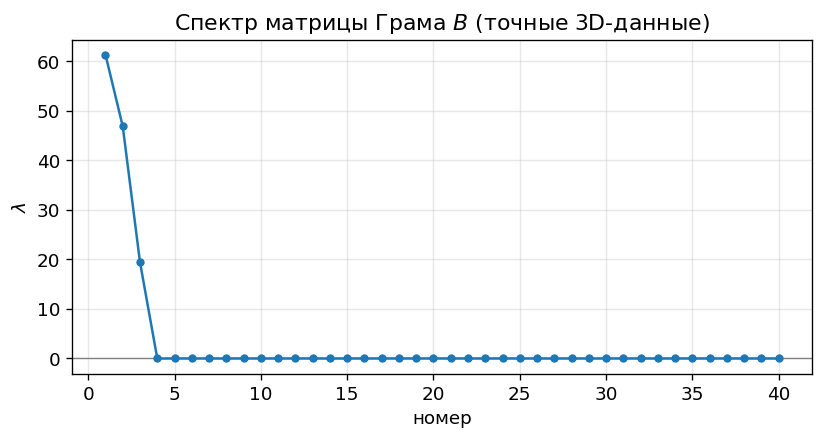

,величина,значение
0,||B-B^T||,6.2e-15
1,# положит.,3
2,# нулевых,37
3,# отрицат.,0
4,rank B,3


In [14]:
B = gram_from_D(D)
vals, vecs = eig_desc(B)
n_pos = int(np.sum(vals > 1e-9))
n_neg = int(np.sum(vals < -1e-9))
n_zero = len(vals) - n_pos - n_neg
fig, ax = plt.subplots(figsize=(7,3.8))
ax.axhline(0, color="gray", lw=0.8)
ax.plot(range(1, len(vals)+1), vals, "o-", ms=4)
ax.set(title="Спектр матрицы Грама $B$ (точные 3D-данные)", xlabel="номер", ylabel=r"$\lambda$")
plt.show()
pd.DataFrame({"величина":["||B-B^T||","# положит.","# нулевых","# отрицат.","rank B"],
              "значение":[f"{np.max(np.abs(B-B.T)):.1e}", n_pos, n_zero, n_neg,
                          np.linalg.matrix_rank(B)]})

**Вывод.** $B$ симметрична; для точных данных из $\mathbb R^3$ ровно 3 положительных
собственных значения, остальные нулевые, $\operatorname{rank}B=3$ — минимальная размерность точного
вложения совпадает с числом положительных собственных значений.

### Дополнительный пример: точки на прямой

В списке данных отдельно указан случай точек на прямой. Для него матрица Грама после центрирования должна иметь один положительный собственный корень, то есть точное вложение имеет размерность 1.


In [ ]:
t = np.linspace(-2, 2, 25)[:, None]
D_line = dist_matrix(t)
B_line = gram_from_D(D_line)
v_line, _ = eig_desc(B_line)

pd.DataFrame({
    "величина": ["# положительных λ", "# отрицательных λ", "rank B", "E_rel при m=1"],
    "значение": [
        int(np.sum(v_line > 1e-9)),
        int(np.sum(v_line < -1e-9)),
        np.linalg.matrix_rank(B_line),
        f"{np.linalg.norm(D_line - dist_matrix(embed(B_line, 1))) / np.linalg.norm(D_line):.2e}"
    ]
})


**Вывод.** Для точек на прямой достаточно одного измерения: ранг матрицы Грама равен 1, а ошибка восстановления расстояний в $\mathbb R^1$ находится на уровне численной погрешности.


## Восстановление координат и сравнение с исходными (пп. 8–9)

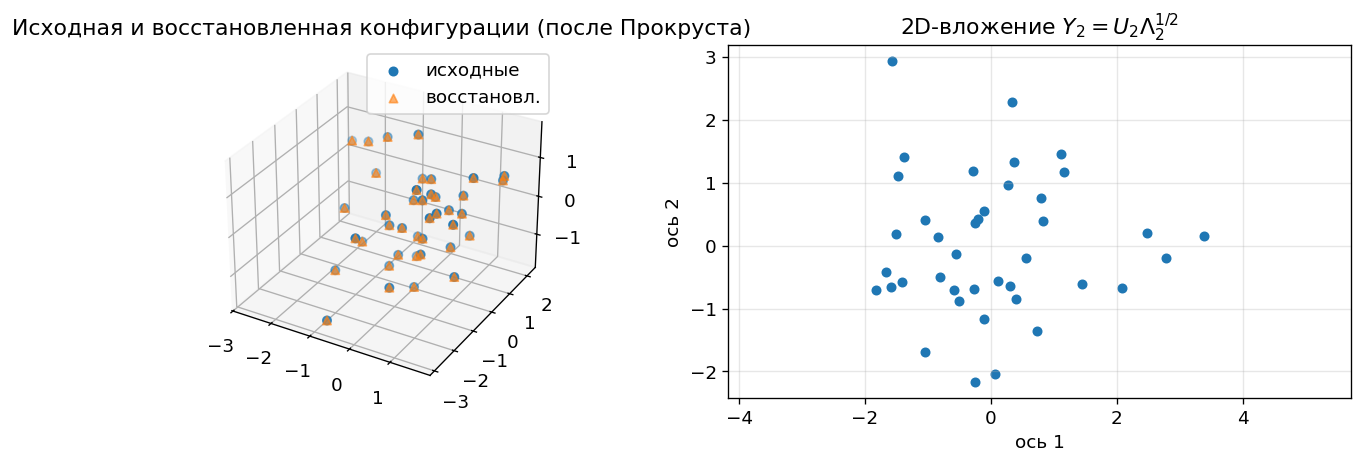

6.708349510575063e-15


In [15]:
Y3 = embed(B, 3)
aligned, Xc = procrustes_align(Y3, X)
fig = plt.figure(figsize=(11,4))
ax1 = fig.add_subplot(1,2,1, projection="3d")
ax1.scatter(*Xc.T, s=25, label="исходные")
ax1.scatter(*aligned.T, s=25, marker="^", alpha=0.6, label="восстановл.")
ax1.set(title="Исходная и восстановленная конфигурации (после Прокруста)")
ax1.legend()
Y2 = embed(B, 2)
ax2 = fig.add_subplot(1,2,2)
ax2.scatter(*Y2.T, s=25)
ax2.set(title="2D-вложение $Y_2=U_2\\Lambda_2^{1/2}$", xlabel="ось 1", ylabel="ось 2")
ax2.axis("equal")
plt.show()
print(np.linalg.norm(aligned - Xc))

**Вывод.** После выравнивания движением (поворот/отражение/сдвиг) восстановленные точки
совпадают с исходными до машинной точности — восстановление с точностью до изометрии.

## Изометричность: ошибки восстановления (п. 10)

In [16]:
Drec = dist_matrix(Y3)
Emax = np.max(np.abs(D - Drec))
EF = np.linalg.norm(D - Drec)
Erel = EF/np.linalg.norm(D)
pd.DataFrame({"ошибка":["E_max","E_F","E_rel"],
              "значение":[f"{Emax:.2e}", f"{EF:.2e}", f"{Erel:.2e}"]})

,ошибка,значение
0,E_max,2.66e-15
1,E_F,2.72e-14
2,E_rel,2.69e-16


**Вывод.** Все три ошибки на уровне машинного нуля — для евклидовых данных вложение точно
изометрично.

## Зависимость ошибки от размерности (п. 12)

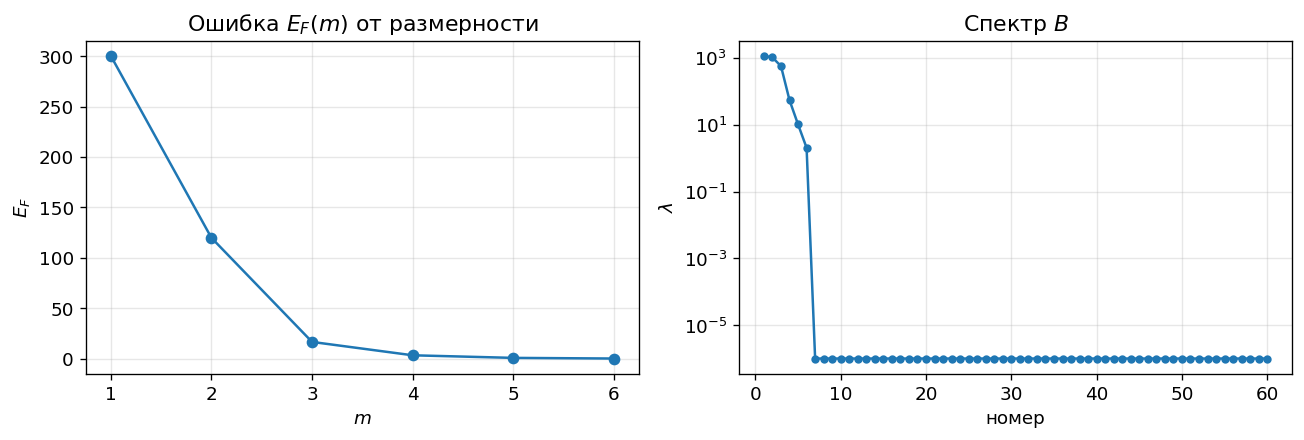

In [17]:
Xhi = rng.normal(size=(60, 6)) @ np.diag([5,4,3,1.0,0.5,0.2])
Dhi = dist_matrix(Xhi)
Bhi = gram_from_D(Dhi)
vhi,_ = eig_desc(Bhi)
mmax = int(np.sum(vhi > 1e-9))
EFm = []
for m in range(1, mmax+1):
    Ym = embed(Bhi, m)
    EFm.append(np.linalg.norm(Dhi - dist_matrix(Ym)))
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].plot(range(1, mmax+1), EFm, "o-")
ax[0].set(title=r"Ошибка $E_F(m)$ от размерности", xlabel="$m$", ylabel="$E_F$")
ax[1].semilogy(range(1, len(vhi)+1), np.clip(vhi,1e-6,None), "o-", ms=4)
ax[1].set(title="Спектр $B$", xlabel="номер", ylabel=r"$\lambda$")
plt.show()

**Вывод.** Ошибка монотонно убывает с ростом $m$ и обращается в ноль при $m=\operatorname{rank}B$.
Поскольку спектр $B$ быстро убывает, уже малая размерность сохраняет почти всю геометрию — это и есть
спектральное сжатие.

## Устойчивость к шуму (п. 13)

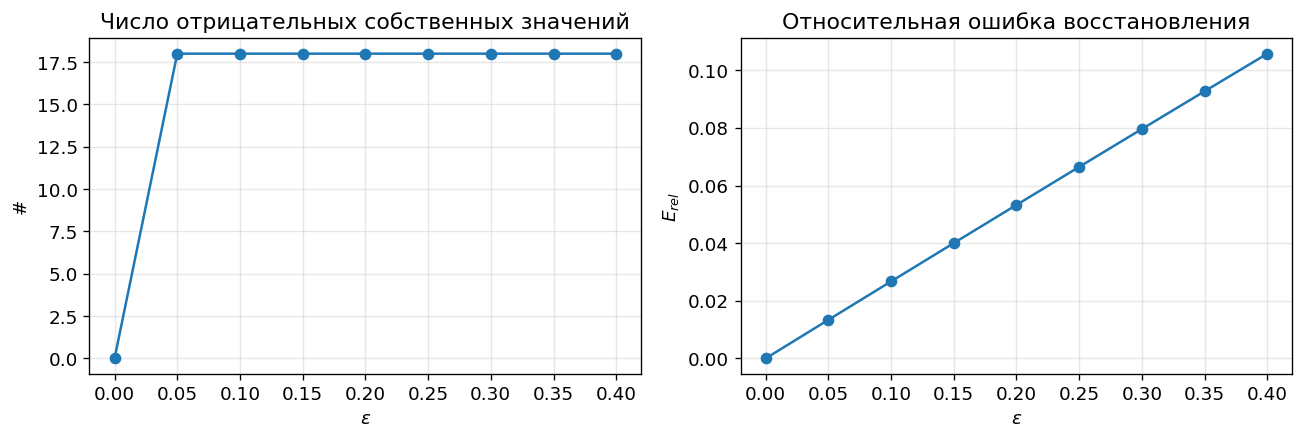

In [18]:
R0 = rng.normal(size=(n,n)); R0 = (R0+R0.T)/2; np.fill_diagonal(R0, 0)
eps_list = np.linspace(0, 0.4, 9)
nneg, erel = [], []
for eps in eps_list:
    De = D + eps*R0
    Be = gram_from_D(De)
    ve,_ = eig_desc(Be)
    nneg.append(int(np.sum(ve < -1e-9)))
    Ye = embed(Be, 3)
    erel.append(np.linalg.norm(De - dist_matrix(Ye))/np.linalg.norm(De))
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].plot(eps_list, nneg, "o-")
ax[0].set(title="Число отрицательных собственных значений", xlabel=r"$\varepsilon$", ylabel="#")
ax[1].plot(eps_list, erel, "o-")
ax[1].set(title="Относительная ошибка восстановления", xlabel=r"$\varepsilon$", ylabel="$E_{rel}$")
plt.show()

**Вывод.** С ростом шума матрица $D$ перестаёт быть евклидовой: у $B$ появляются отрицательные
собственные значения, а ошибка восстановления растёт примерно линейно по $\varepsilon$.

## Визуализация vs точность: диаграмма Шепарда (п. 14)

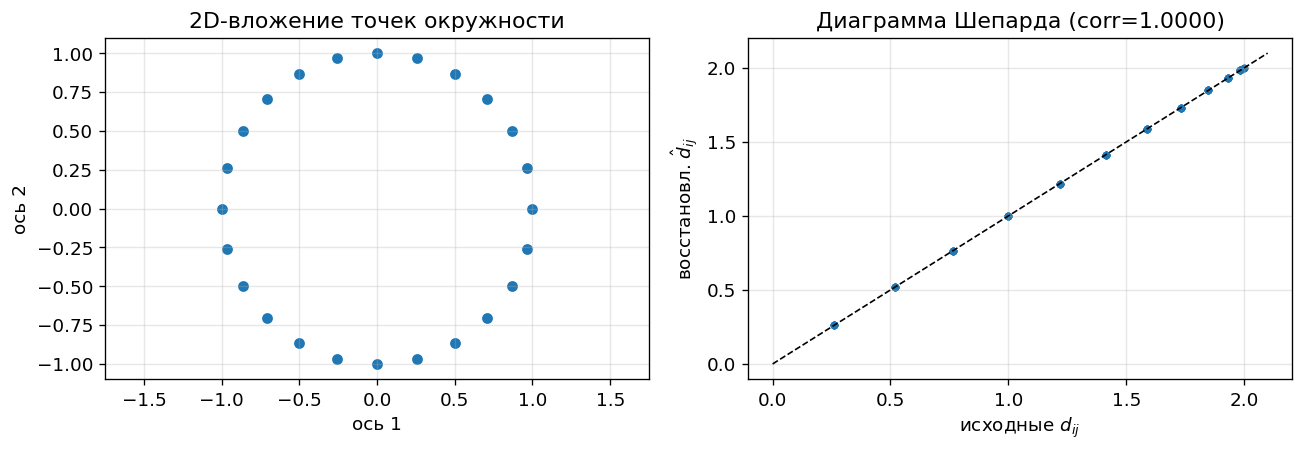

In [19]:
th = np.linspace(0, 2*np.pi, 24, endpoint=False)
Circle = np.c_[np.cos(th), np.sin(th)]
Dc = dist_matrix(Circle)
Bc = gram_from_D(Dc)
Y2c = embed(Bc, 2)
Drecc = dist_matrix(Y2c)
iu = np.triu_indices(len(Dc), 1)
corr = np.corrcoef(Dc[iu], Drecc[iu])[0,1]
fig, ax = plt.subplots(1,2, figsize=(11,3.9))
ax[0].scatter(*Y2c.T, s=30)
ax[0].set(title="2D-вложение точек окружности", xlabel="ось 1", ylabel="ось 2"); ax[0].axis("equal")
ax[1].scatter(Dc[iu], Drecc[iu], s=12, alpha=0.6)
lim = [0, Dc.max()*1.05]; ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set(title=f"Диаграмма Шепарда (corr={corr:.4f})",
          xlabel="исходные $d_{ij}$", ylabel="восстановл. $\\hat d_{ij}$")
plt.show()

**Вывод.** Точки окружности (внутренняя размерность 2) восстанавливаются точно: облако на
диаграмме Шепарда ложится на диагональ, корреляция $\approx1$ — визуально удачный и количественно
точный случай совпадают.

### Сравнение визуально удачного и количественно точного случая (п. 14d)

Точный случай — окружность с обычными евклидовыми расстояниями: точки действительно лежат в $\mathbb R^2$, поэтому 2D-вложение восстанавливает расстояния почти без ошибки.

Неточный случай ниже — сфера с геодезическими расстояниями. Такая визуализация может выглядеть осмысленно как «карта», но количественно она не является точным евклидовым вложением: у матрицы Грама появляются отрицательные собственные значения, а часть информации неизбежно теряется при отбрасывании этих мод.


## Данные: сфера с геодезическими расстояниями (неевклидов случай)

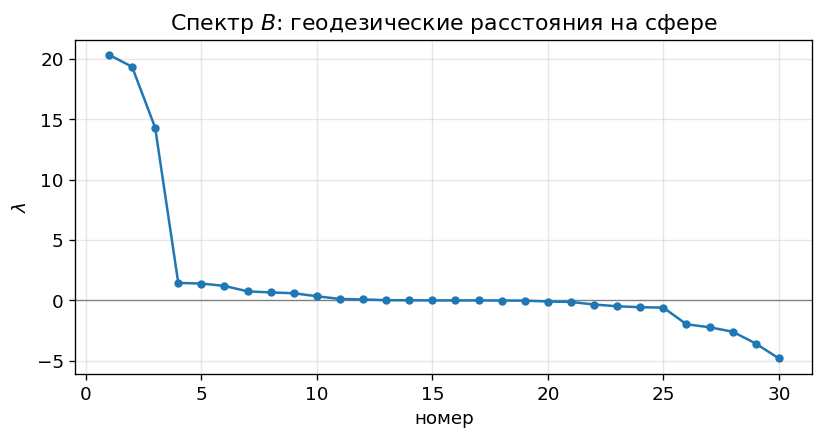

15


In [20]:
pts = rng.normal(size=(30,3)); pts /= np.linalg.norm(pts, axis=1, keepdims=True)
Dg = np.arccos(np.clip(pts @ pts.T, -1, 1))
Bg = gram_from_D(Dg)
vg,_ = eig_desc(Bg)
fig, ax = plt.subplots(figsize=(7,3.8))
ax.axhline(0, color="gray", lw=0.8)
ax.plot(range(1, len(vg)+1), vg, "o-", ms=4)
ax.set(title="Спектр $B$: геодезические расстояния на сфере", xlabel="номер", ylabel=r"$\lambda$")
plt.show()
print(int(np.sum(vg < -1e-9)))

**Вывод.** Геодезические (дуговые) расстояния на сфере не вкладываются в евклидово пространство
изометрично: у $B$ есть заметные **отрицательные** собственные значения. MDS даёт лишь приближённую
плоскую «карту», отбрасывая эти моды, — классический источник искажений в картографии.